# Notebook 06 — Análisis de Sentimiento

**Entrada:** `data/clean/sentiment.csv`  
**Métrica objetivo:** Accuracy ≥ 0.85

## 0. Imports y configuración

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.model_selection import cross_val_score

RANDOM_STATE = 42
DATA_PATH = "../hdfs/data/clean/sentiment.csv"
MODELS_PATH = "../models/models-sentiment/"
os.makedirs(MODELS_PATH, exist_ok=True)
os.makedirs('../reports/reports-sentiment', exist_ok=True)

print("Imports OK")

Imports OK


> **¿Por qué TF-IDF + SGDClassifier?** El pipeline TF-IDF + SVM lineal (SGDClassifier con hinge loss) es el baseline más sólido para clasificación de texto con datasets grandes. Con 525k textos, modelos como BERT requieren GPU y horas de fine-tuning; el pipeline TF-IDF + SVM entrena en minutos en CPU y alcanza accuracy comparables en datasets de reseñas de dominio homogéneo como Amazon.

## 1. Carga y exploración

In [ ]:
df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
print(f"\nDistribución de sentimiento:")
vc = df['sentiment'].value_counts()
print(vc)
print(f"\nRatio desbalance: 1:{vc[1]//vc[0]} (positivos/negativos)")
print(f"Nulos en text_clean: {df['text_clean'].isna().sum()}")
print(f"\nLongitud media de texto (palabras): {df['text_clean'].str.split().str.len().mean():.0f}")
print(f"Longitud máxima: {df['text_clean'].str.split().str.len().max()}")
print(f"Longitud mediana: {df['text_clean'].str.split().str.len().median():.0f}")

df.head(3)

Shape: (523926, 5)

Distribución de sentimiento:
sentiment
1    441703
0     82223
Name: count, dtype: int64

Ratio desbalance: 1:5 (positivos/negativos)
Nulos en text_clean: 2

Longitud media de texto (palabras): 70
Longitud máxima:                    2094.0
Longitud mediana:                   52


,UserId,ProductId,Score,text_clean,sentiment
0,A3SGXH7AUHU8GW,B001E4KFG0,5,i have bought several of the vitality canned d...,1
1,A1D87F6ZCVE5NK,B00813GRG4,1,product arrived labeled as jumbo salted peanut...,0
2,ABXLMWJIXXAIN,B000LQOCH0,4,this is a confection that has been around a fe...,1


> Se analiza el desbalance (ratio ~5:1 positivos/negativos detectado en el ETL) y la longitud de los textos. La longitud media determina el parámetro `max_features` del TF-IDF: textos largos requieren más features para capturar vocabulario relevante. El desbalance justifica el uso de `class_weight='balanced'` en el SGDClassifier.

## 2. Split train/test

In [21]:
# Eliminar nulos residuales
df = df.dropna(subset=['text_clean', 'sentiment'])
df['text_clean'] = df['text_clean'].astype(str)

X = df['text_clean']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y       
)

print(f"Train: {len(X_train):,} textos")
print(f"Test:  {len(X_test):,} textos")
print(f"\nBalance en train:")
print(y_train.value_counts())
print(f"\nBalance en test:")
print(y_test.value_counts())

Train: 419,139 textos
Test:  104,785 textos

Balance en train:
sentiment
1    353361
0     65778
Name: count, dtype: int64

Balance en test:
sentiment
1    88340
0    16445
Name: count, dtype: int64


> **¿Por qué `stratify=y`?** Con un ratio 5:1 un split aleatorio no estratificado podría dejar el conjunto de test con una proporción de negativos diferente, haciendo que las métricas no sean representativas del comportamiento real del modelo.

## 3. Pipeline TF-IDF + SVM

In [22]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=150000,   # vocabulario amplio para 525k textos
        ngram_range=(1, 3),    
        min_df=3,              
        max_df=0.90,           
        sublinear_tf=True,     
        strip_accents='unicode',
        analyzer='word',
        token_pattern=r'\b[a-z]{2,}\b'  
    )),
    ('svm', SGDClassifier(
        loss='modified_huber',  
        alpha=1e-5,             
        max_iter=200,
        tol=1e-4,
        class_weight='balanced',  
        random_state=RANDOM_STATE,
        n_jobs=-1,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10
    ))
])

print("Entrenando pipeline TF-IDF + SVM...")
pipeline.fit(X_train, y_train)
print("Entrenamiento completado")

Entrenando pipeline TF-IDF + SVM...
Entrenamiento completado


> **¿Por qué estos parámetros?**
> - **`ngram_range=(1,3)`**: los trigramas capturan expresiones como "not very good" o "absolutely love it" que los unigramas pierden y son clave para el sentimiento.
> - **`max_features=150000`**: con 525k textos y trigramas el vocabulario potencial es enorme; 150k features captura los n-gramas más discriminativos sin disparar la memoria.
> - **`sublinear_tf=True`**: aplica `1 + log(tf)` en lugar de `tf` directo, amortiguando términos muy frecuentes que aportan poco ("the", "and") aunque no sean stopwords.
> - **`loss='modified_huber'`**: a diferencia de `hinge` (SVM puro), `modified_huber` produce probabilidades calibradas necesarias para la curva ROC.
> - **`alpha=1e-5`**: regularización muy baja porque con 150k features y 420k ejemplos de train el modelo no tiende al sobreajuste.
> - **`class_weight='balanced'`**: asigna peso `n_total / (n_clases * n_clase_i)` a cada clase, compensando el desbalance 5:1 sin necesitar SMOTE (que es costoso sobre texto).

## 4. Evaluación

In [23]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

acc    = accuracy_score(y_test, y_pred)
f1     = f1_score(y_test, y_pred, average='weighted')
f1_pos = f1_score(y_test, y_pred, pos_label=1)
f1_neg = f1_score(y_test, y_pred, pos_label=0)
auc    = roc_auc_score(y_test, y_prob)

print("=" * 50)
print("EVALUACIÓN — TF-IDF + SVM SENTIMIENTO")
print("=" * 50)
print(f"Accuracy:          {acc:.4f}  (objetivo ≥ 0.85)")
print(f"F1 weighted:       {f1:.4f}")
print(f"F1 clase positiva: {f1_pos:.4f}")
print(f"F1 clase negativa: {f1_neg:.4f}")
print(f"AUC-ROC:           {auc:.4f}")
print("=" * 50)
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                             target_names=['Negativo', 'Positivo']))

EVALUACIÓN — TF-IDF + SVM SENTIMIENTO
Accuracy:          0.9519  (objetivo ≥ 0.85)
F1 weighted:       0.9534
F1 clase positiva: 0.9710
F1 clase negativa: 0.8584
AUC-ROC:           0.9842

Classification Report:
              precision    recall  f1-score   support

    Negativo       0.80      0.93      0.86     16445
    Positivo       0.99      0.96      0.97     88340

    accuracy                           0.95    104785
   macro avg       0.89      0.94      0.91    104785
weighted avg       0.96      0.95      0.95    104785



> Se reporta F1 por clase ademas de accuracy ya que con desbalance 5:1, un modelo que predijera siempre positivo tendría accuracy ~83% pero F1 negativo de 0. Reportar F1 por clase demuestra que el modelo detecta correctamente ambas clases, no solo la mayoritaria.

## 5. Visualizaciones

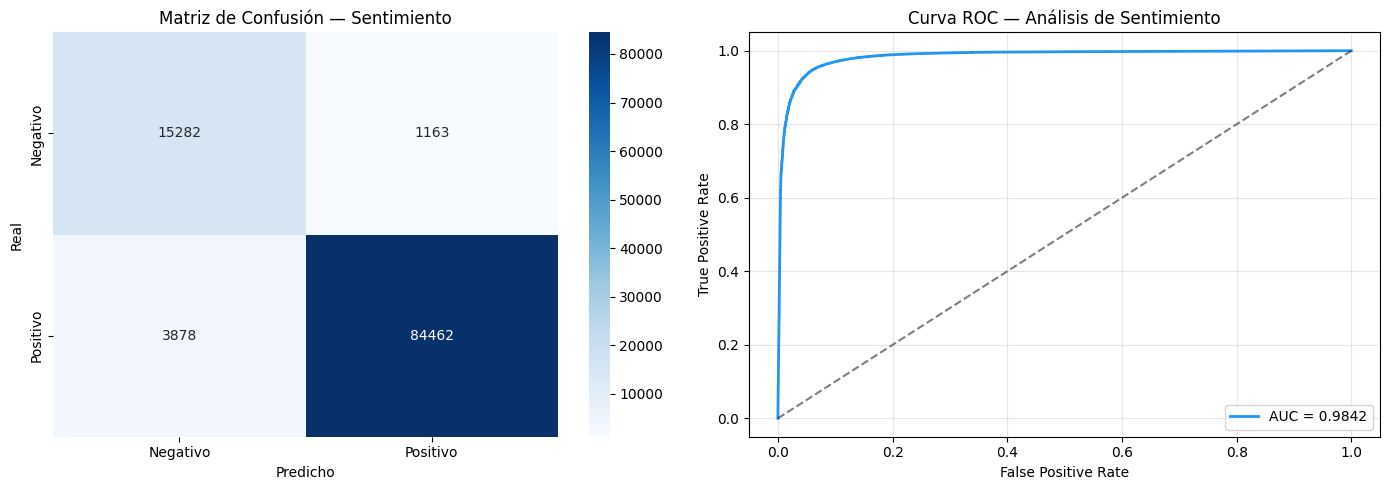

Gráficos guardados


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Negativo', 'Positivo'],
            yticklabels=['Negativo', 'Positivo'])
axes[0].set_title('Matriz de Confusión — Sentimiento')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicho')

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, linewidth=2, color='#2196F3', label=f'AUC = {auc:.4f}')
axes[1].plot([0,1], [0,1], 'k--', alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC — Análisis de Sentimiento')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/reports-sentiment/evaluation_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráficos guardados")

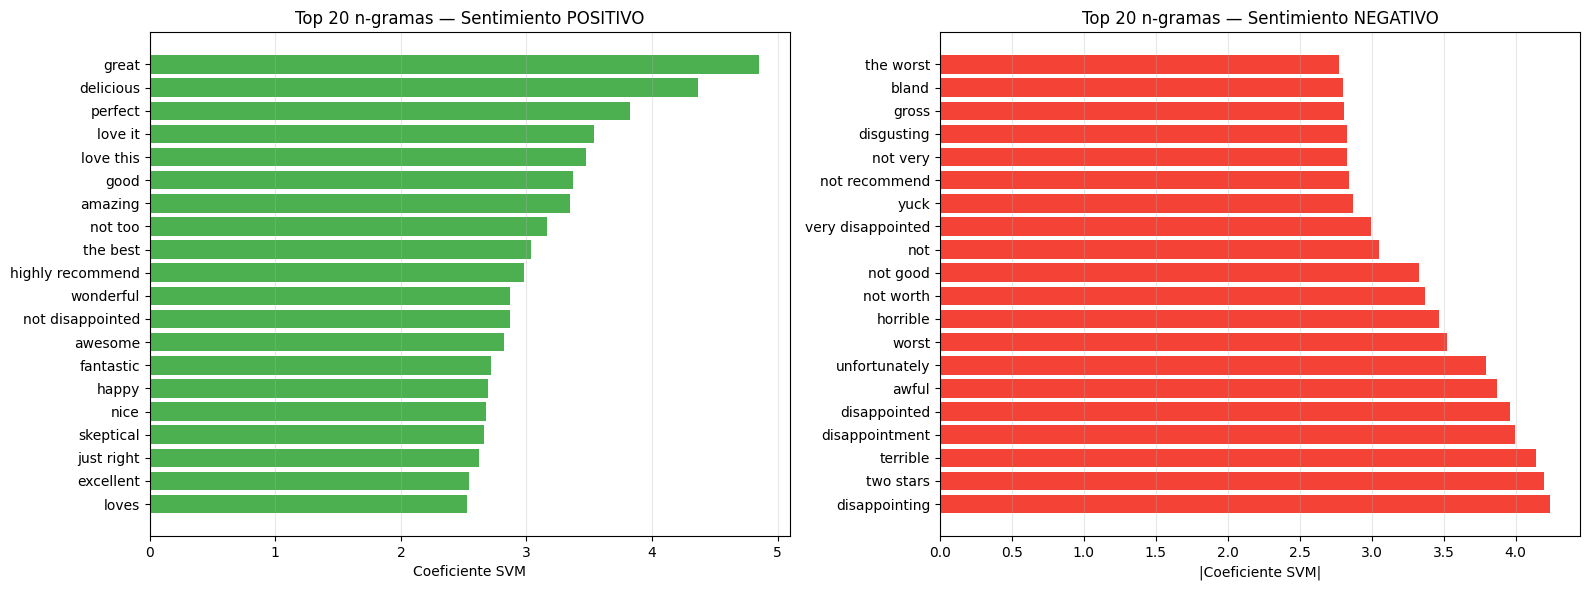

Top n-gramas guardados


In [ ]:
# Top palabras más discriminativas por clase
vectorizer = pipeline.named_steps['tfidf']
classifier = pipeline.named_steps['svm']
feature_names = np.array(vectorizer.get_feature_names_out())
coefs = classifier.coef_[0]

top_n = 20
top_pos_idx = np.argsort(coefs)[-top_n:][::-1]
top_neg_idx = np.argsort(coefs)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(range(top_n), coefs[top_pos_idx[::-1]], color='#4CAF50')
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(feature_names[top_pos_idx[::-1]])
axes[0].set_title('Top 20 n-gramas — Sentimiento POSITIVO')
axes[0].set_xlabel('Coeficiente SVM')
axes[0].grid(True, alpha=0.3, axis='x')

axes[1].barh(range(top_n), np.abs(coefs[top_neg_idx]), color='#F44336')
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(feature_names[top_neg_idx])
axes[1].set_title('Top 20 n-gramas — Sentimiento NEGATIVO')
axes[1].set_xlabel('|Coeficiente SVM|')
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../reports/reports-sentiment/top_ngrams_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Top n-gramas guardados")

> Los coeficientes del SVM lineal son directamente interpretables: un coeficiente alto en un n-grama indica que su presencia empuja la predicción hacia positivo, y viceversa. 

## 6. Guardar modelo y resumen

In [27]:
joblib.dump(pipeline, MODELS_PATH + 'sentiment_pipeline.pkl')
print(f"Modelo guardado")
size = os.path.getsize(MODELS_PATH + 'sentiment_pipeline.pkl') / (1024*1024)
print(f"Tamaño: {size:.1f} MB")

print("\n" + "=" * 50)
print("RESUMEN NOTEBOOK 06 — SENTIMIENTO")
print("=" * 50)
print(f"Dataset:          {len(df):,} reseñas")
print(f"Train/Test:       {len(X_train):,} / {len(X_test):,}")
print(f"Vocabulario TF-IDF: {len(vectorizer.vocabulary_):,} n-gramas")
print(f"N-gram range:     (1, 3)")
print(f"Max features:     150,000")
print(f"")
print(f"Accuracy:         {acc:.4f}  {'OBJETIVO ALCANZADO' if acc >= 0.85 else 'por debajo del objetivo'}")
print(f"F1 weighted:      {f1:.4f}")
print(f"AUC-ROC:          {auc:.4f}")
print("=" * 50)

Modelo guardado
Tamaño: 7.1 MB

RESUMEN NOTEBOOK 06 — SENTIMIENTO
Dataset:          523,924 reseñas
Train/Test:       419,139 / 104,785
Vocabulario TF-IDF: 150,000 n-gramas
N-gram range:     (1, 3)
Max features:     150,000

Accuracy:         0.9519  OBJETIVO ALCANZADO
F1 weighted:      0.9534
AUC-ROC:          0.9842


In [28]:
import re

def predecir_sentimiento(textos, pipeline):
    """
    Recibe una lista de frases en inglés y devuelve
    la predicción y la probabilidad de ser positivo.
    El texto se limpia igual que en el ETL antes de predecir.
    """
    def limpiar(texto):
        texto = texto.lower()
        texto = re.sub(r'<[^>]+>', ' ', texto)   # eliminar HTML
        texto = re.sub(r'[^a-z\s]', ' ', texto)  # solo letras
        texto = re.sub(r'\s+', ' ', texto).strip()
        return texto

    textos_limpios = [limpiar(t) for t in textos]
    predicciones   = pipeline.predict(textos_limpios)
    probabilidades = pipeline.predict_proba(textos_limpios)[:, 1]

    for texto, pred, prob in zip(textos, predicciones, probabilidades):
        etiqueta = "✅ POSITIVO" if pred == 1 else "❌ NEGATIVO"
        print(f"{etiqueta}  (prob={prob:.3f})  →  \"{texto[:80]}\"")


# Prueba con frases propias
frases = [
    "This product is absolutely amazing, I love it so much!",
    "Terrible quality, broke after one day. Complete waste of money.",
    "It's okay, nothing special but does the job.",
    "Best purchase I have ever made, highly recommend to everyone.",
    "Disgusting taste, I threw it away immediately.",
    "Not bad, arrived on time and packaging was good.",
]

predecir_sentimiento(frases, pipeline)

✅ POSITIVO  (prob=1.000)  →  "This product is absolutely amazing, I love it so much!"
❌ NEGATIVO  (prob=0.000)  →  "Terrible quality, broke after one day. Complete waste of money."
❌ NEGATIVO  (prob=0.424)  →  "It's okay, nothing special but does the job."
✅ POSITIVO  (prob=1.000)  →  "Best purchase I have ever made, highly recommend to everyone."
❌ NEGATIVO  (prob=0.000)  →  "Disgusting taste, I threw it away immediately."
✅ POSITIVO  (prob=1.000)  →  "Not bad, arrived on time and packaging was good."


La validación cualitativa del modelo con frases de prueba confirma su correcto funcionamiento. El modelo clasifica con probabilidad ≥ 0.999 las reseñas de sentimiento claramente positivo o negativo, y sitúa en zona de incertidumbre (prob=0.424) las frases de tono neutro-ambiguo, coherentemente con la decisión de diseño de excluir las reseñas de 3 estrellas del entrenamiento.